# Solution Notebook

In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import statsmodels.api as sm

#### Data Loading and Split

In [82]:
# Load source files
bike = pd.read_csv('bike_project_data/bike_counts.csv', parse_dates=['datetime'])
weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', parse_dates=['datetime'])
stations = pd.read_csv('bike_project_data/stations.csv')
holidays = pd.read_csv('bike_project_data/danish_holidays.csv', parse_dates=['date'])

print('bike:', bike.shape)
print('weather:', weather.shape)
print('stations:', stations.shape)
print('holidays:', holidays.shape)


bike: (157680, 5)
weather: (26280, 4)
stations: (6, 4)
holidays: (36, 2)


In [83]:
# Merge hourly bike observations with weather
df = bike.merge(weather, on='datetime', how='left')

# Calendar features
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

holiday_dates = set(holidays['date'].dt.date)
df['is_holiday'] = df['date'].isin(holiday_dates).astype(int)

# Sort chronologically
df = df.sort_values(['datetime', 'station']).reset_index(drop=True)

print('Merged df (target-complete):', df.shape)
print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
print('Missing bike_count (%):', round(df['bike_count'].isna().mean() * 100, 2))

Merged df (target-complete): (157680, 14)
Date range: 2021-01-01 00:00:00 to 2023-12-31 23:00:00
Missing bike_count (%): 1.99


To handle missing values, rows with missing bike_count are dropped, since models require observations for training and evaluation.

In [84]:
# Drop missing target rows before split (cannot train/evaluate without y)
df = df.dropna(subset=['bike_count']).copy()

print('Missing bike_count (%):', round(df['bike_count'].isna().mean() * 100, 2))

Missing bike_count (%): 0.0


In [85]:
# Chronological split
train_start = pd.Timestamp('2021-01-01 00:00:00')
train_end   = pd.Timestamp('2022-06-30 23:00:00')
val_start   = pd.Timestamp('2022-07-01 00:00:00')
val_end     = pd.Timestamp('2022-12-31 23:00:00')
test_start  = pd.Timestamp('2023-01-01 00:00:00')
test_end    = pd.Timestamp('2023-12-31 23:00:00')

train_df = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)].copy()
val_df   = df[(df['datetime'] >= val_start) & (df['datetime'] <= val_end)].copy()
test_df  = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)].copy()

print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)


Train shape: (77025, 14)
Val shape:   (25971, 14)
Test shape:  (51551, 14)


#### Plots

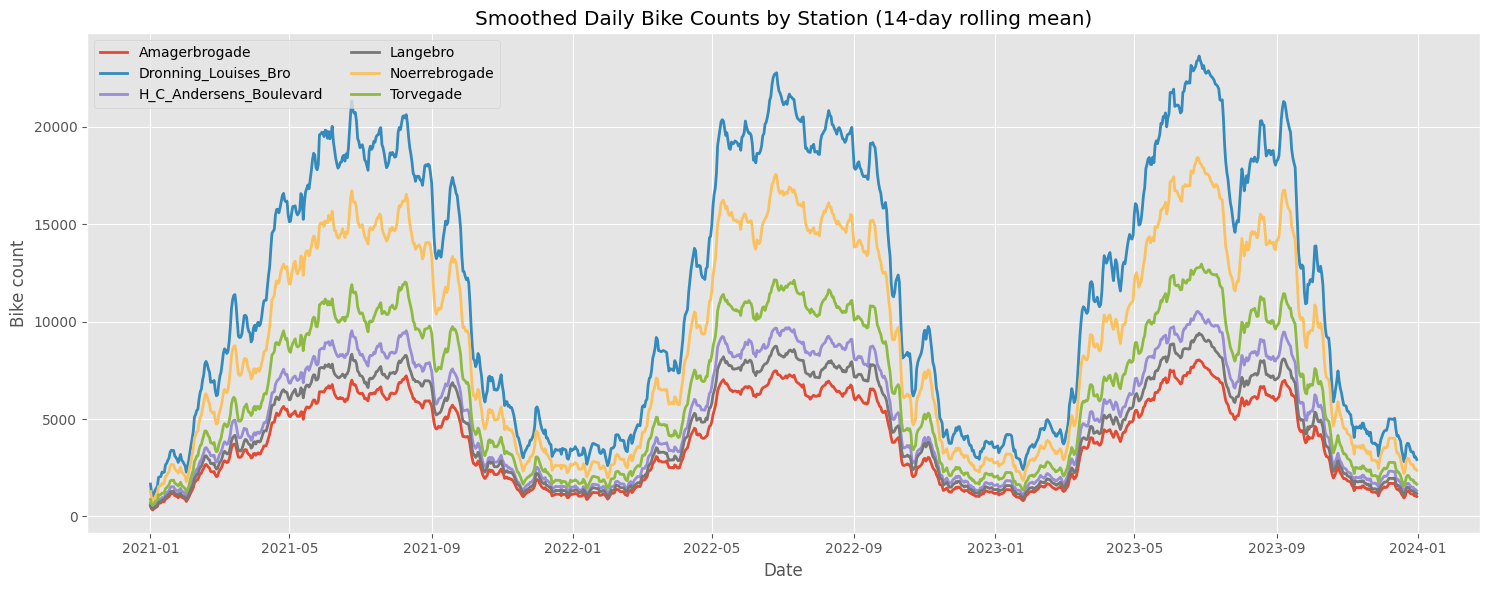

In [86]:
station_daily = df.groupby(['date', 'station'], as_index=False)['bike_count'].sum(min_count=1)
station_daily['date'] = pd.to_datetime(station_daily['date'])

fig, ax = plt.subplots(figsize=(15, 6))
for station in sorted(station_daily['station'].unique()):
    g = station_daily[station_daily['station'] == station].sort_values('date')
    smooth = g['bike_count'].rolling(14, min_periods=1).mean()
    ax.plot(g['date'], smooth, linewidth=2, label=station)

ax.set_title('Smoothed Daily Bike Counts by Station (14-day rolling mean)')
ax.set_xlabel('Date')
ax.set_ylabel('Bike count')
ax.legend(ncol=2, frameon=True)
plt.tight_layout()
plt.show()

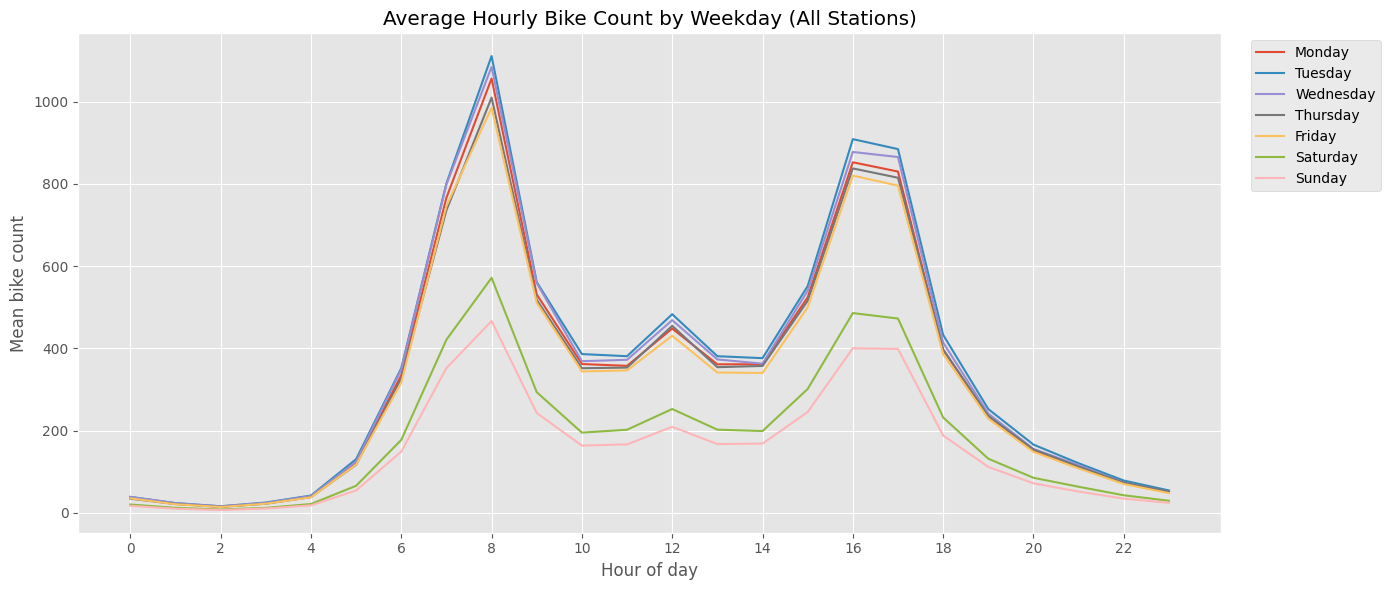

In [87]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_profile = df.groupby(['day_of_week', 'hour'], as_index=False)['bike_count'].mean()
weekday_profile['weekday_name'] = weekday_profile['day_of_week'].map({
    0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'
})
weekday_profile['weekday_name'] = pd.Categorical(weekday_profile['weekday_name'], categories=weekday_order, ordered=True)
weekday_profile = weekday_profile.sort_values(['weekday_name', 'hour'])

fig, ax = plt.subplots(figsize=(14, 6))
for day in weekday_order:
    g = weekday_profile[weekday_profile['weekday_name'] == day]
    ax.plot(g['hour'], g['bike_count'], label=day)

ax.set_title('Average Hourly Bike Count by Weekday (All Stations)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean bike count')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

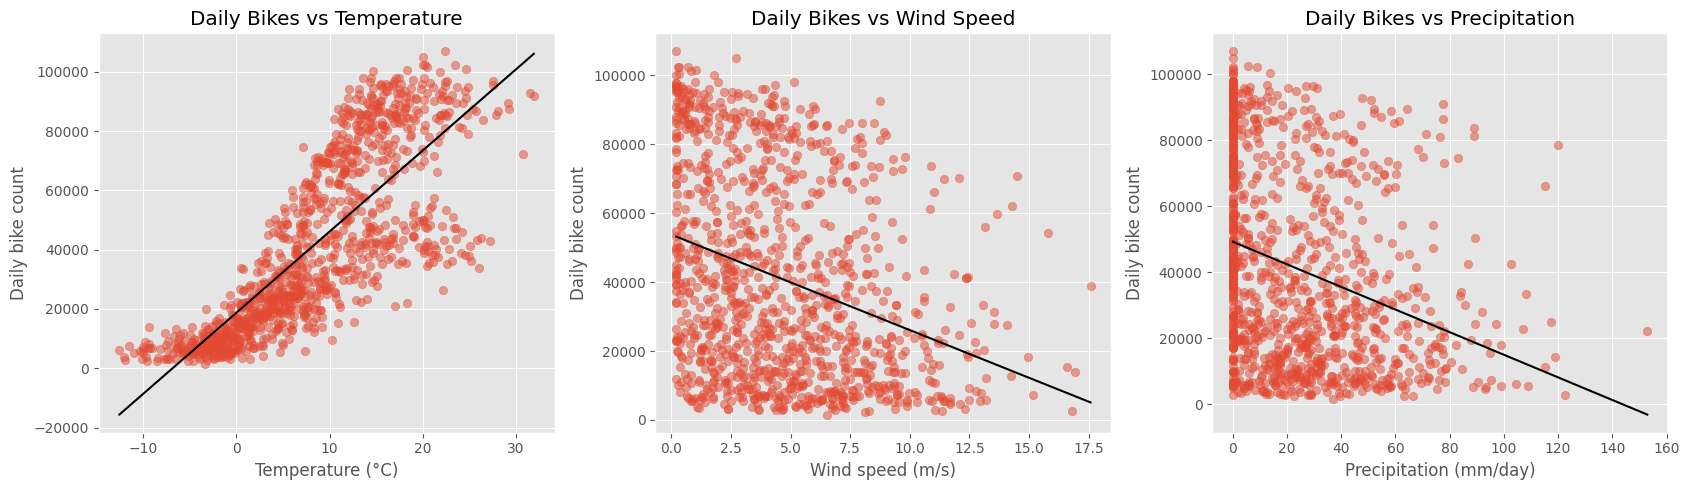

In [88]:
daily_merged = (
    df.groupby('date', as_index=False)
    .agg(
        daily_bikes=('bike_count', 'sum'),
        temp=('temperature_C', 'mean'),
        wind=('wind_speed_ms', 'mean'),
        precip=('precipitation_mm', 'sum')
    )
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(daily_merged['temp'], daily_merged['daily_bikes'], alpha=0.5)
coef = np.polyfit(daily_merged['temp'], daily_merged['daily_bikes'], 1)
x = np.linspace(daily_merged['temp'].min(), daily_merged['temp'].max(), 100)
axes[0].plot(x, coef[0] * x + coef[1], color='black')
axes[0].set_title('Daily Bikes vs Temperature')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Daily bike count')

axes[1].scatter(daily_merged['wind'], daily_merged['daily_bikes'], alpha=0.5)
coef = np.polyfit(daily_merged['wind'], daily_merged['daily_bikes'], 1)
x = np.linspace(daily_merged['wind'].min(), daily_merged['wind'].max(), 100)
axes[1].plot(x, coef[0] * x + coef[1], color='black')
axes[1].set_title('Daily Bikes vs Wind Speed')
axes[1].set_xlabel('Wind speed (m/s)')
axes[1].set_ylabel('Daily bike count')

axes[2].scatter(daily_merged['precip'], daily_merged['daily_bikes'], alpha=0.5)
coef = np.polyfit(daily_merged['precip'], daily_merged['daily_bikes'], 1)
x = np.linspace(daily_merged['precip'].min(), daily_merged['precip'].max(), 100)
axes[2].plot(x, coef[0] * x + coef[1], color='black')
axes[2].set_title('Daily Bikes vs Precipitation')
axes[2].set_xlabel('Precipitation (mm/day)')
axes[2].set_ylabel('Daily bike count')

plt.tight_layout()
plt.show()

The data shows clear seasonal trends, with higher bike counts across all stations during summer. This is supported by the weather analysis, where temperature appears to be the strongest predictor of bike count. Correlations between bike count and both wind speed and precipitation are negative, but with substantial variability, especially at low values. Finally, hour of day and day of week are consistent indicators of bike count across all six stations, with weekday peaks in the morning and afternoon showing the highest traffic.

#### Linear Regression: Dronning Louises Bro

In [89]:
station_name = 'Dronning_Louises_Bro'

train_s = train_df[train_df['station'] == station_name].copy()
val_s = val_df[val_df['station'] == station_name].copy()
test_s = test_df[test_df['station'] == station_name].copy()

print('Station:', station_name)
print('Train:', train_s.shape)
print('Val:  ', val_s.shape)
print('Test: ', test_s.shape)

Station: Dronning_Louises_Bro
Train: (12879, 14)
Val:   (4334, 14)
Test:  (8581, 14)


In [90]:
target = 'bike_count'
features = ['temperature_C', 'wind_speed_ms', 'precipitation_mm', 'hour', 'day_of_week', 'month']

X_train = train_s[features]
y_train = train_s[target]
X_val = val_s[features]
y_val = val_s[target]
X_test = test_s[features]
y_test = test_s[target]

# OLS
X_train_sm = sm.add_constant(X_train, has_constant='add')
X_val_sm = sm.add_constant(X_val, has_constant='add')
X_test_sm = sm.add_constant(X_test, has_constant='add')

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary(slim=True))

y_val_pred = ols_model.predict(X_val_sm)
y_test_pred = ols_model.predict(X_test_sm)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

print('Validation metrics:')
print('MAE :', round(mae(y_val, y_val_pred), 2))
print('RMSE:', round(rmse(y_val, y_val_pred), 2))
print('R2  :', round(r2(y_val, y_val_pred), 4))

                            OLS Regression Results                            
Dep. Variable:             bike_count   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.309
No. Observations:               12879   F-statistic:                     960.8
Covariance Type:            nonrobust   Prob (F-statistic):               0.00
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              254.4352     15.916     15.986      0.000     223.237     285.634
temperature_C       35.4417      0.536     66.171      0.000      34.392      36.492
wind_speed_ms       -5.5549      1.240     -4.479      0.000      -7.986      -3.124
precipitation_mm   -80.4937      9.482     -8.489      0.000     -99.079     -61.908
hour                 7.9845      0.675     11.824      0.000       6.661       9.308
day_of_wee

In [91]:
# X^T X
XtX = X_train_sm.T @ X_train_sm
XtX

,const,temperature_C,wind_speed_ms,precipitation_mm,hour,day_of_week,month
const,12879.0,105820.00,55238.30,2240.00,148232.0,38631.0,71151.0
temperature_C,105820.0,1899240.06,361206.08,14576.81,1238119.6,312656.4,583570.1
wind_speed_ms,55238.3,361206.08,428992.01,10560.10,636723.2,170567.1,297959.1
precipitation_mm,2240.0,14576.81,10560.10,3539.38,26615.4,6672.7,11634.7
hour,148232.0,1238119.60,636723.20,26615.40,2323592.0,444874.0,818797.0
day_of_week,38631.0,312656.40,170567.10,6672.70,444874.0,167435.0,212826.0
month,71151.0,583570.10,297959.10,11634.70,818797.0,212826.0,533925.0


In [92]:
eigvals = np.linalg.eigvalsh(XtX)
cond_number = np.linalg.cond(XtX)

print("Min eigenvalue:", eigvals.min())
print("Max eigenvalue:", eigvals.max())
print("Condition number:", cond_number)

Min eigenvalue: 1093.1427842998546
Max eigenvalue: 3970224.605642263
Condition number: 3631.9359764016813


#### Predictions vs actual counts

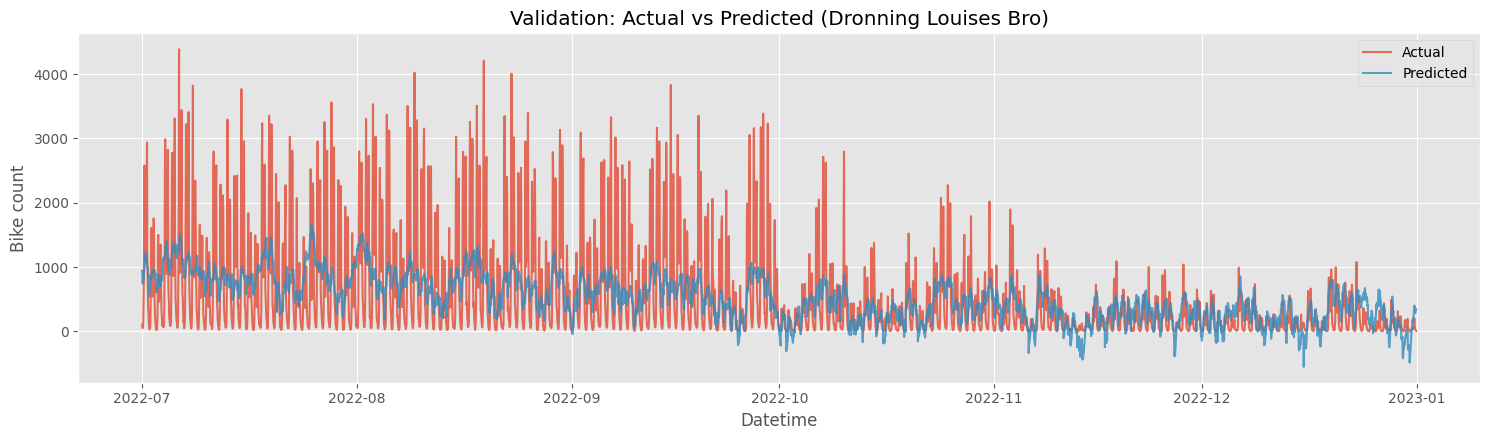

In [93]:
# Time-series overlay
val_plot = val_s[['datetime', 'bike_count']].copy()
val_plot['pred'] = y_val_pred
val_plot = val_plot.sort_values('datetime')

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(val_plot['datetime'], val_plot['bike_count'], label='Actual', alpha=0.8)
ax.plot(val_plot['datetime'], val_plot['pred'], label='Predicted', alpha=0.8)
ax.set_title('Validation: Actual vs Predicted (Dronning Louises Bro)')
ax.set_xlabel('Datetime')
ax.set_ylabel('Bike count')
ax.legend()
plt.tight_layout()
plt.show()

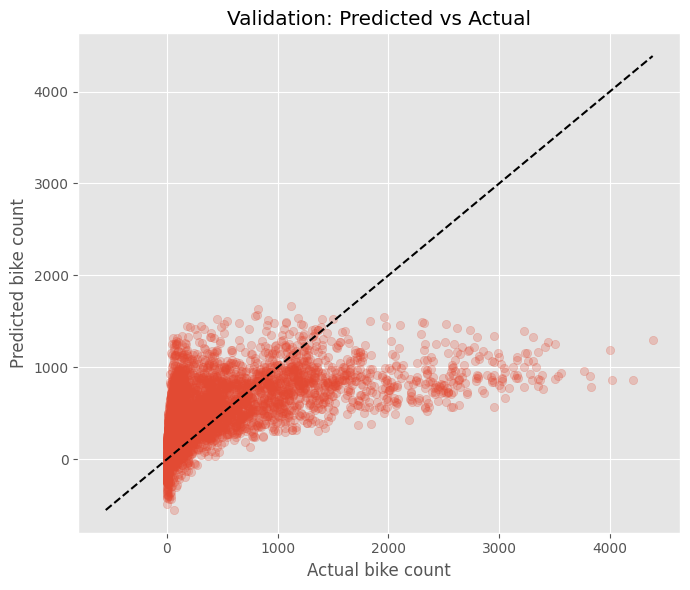

In [94]:
# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(val_plot['bike_count'], val_plot['pred'], alpha=0.25)
lims = [
    min(val_plot['bike_count'].min(), val_plot['pred'].min()),
    max(val_plot['bike_count'].max(), val_plot['pred'].max())
]
ax.plot(lims, lims, 'k--', linewidth=1.5)
ax.set_title('Validation: Predicted vs Actual')
ax.set_xlabel('Actual bike count')
ax.set_ylabel('Predicted bike count')
plt.tight_layout()
plt.show()

The model dramatically underpredicts for large counts and systematically overpredicts for lower counts.

#### Feature engineering

In [95]:
def feature_engineering(data):
    d = data.copy()

    # cyclical temporal features
    for k in [1, 2]:
        d[f'hour_sin_{k}'] = np.sin(k * 2 * np.pi * d['hour'] / 24)
        d[f'hour_cos_{k}'] = np.cos(k * 2 * np.pi * d['hour'] / 24)

    d['dow_sin'] = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos'] = np.cos(2 * np.pi * d['day_of_week'] / 7)

    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)

    # wheather transformations
    d['temperature_sq'] = d['temperature_C'] ** 2
    d['wind_sq'] = d['wind_speed_ms'] ** 2
    d['is_raining'] = (d['precipitation_mm'] > 0.1).astype(int)
    d['log_precip'] = np.log1p(d['precipitation_mm'])

    # interactions
    for k in [1, 2]:
        d[f"temp_x_hour_sin_{k}"] = d["temperature_C"] * d[f"hour_sin_{k}"]
        d[f"temp_x_hour_cos_{k}"] = d["temperature_C"] * d[f"hour_cos_{k}"]

    # indicator variables
    d['is_weekend'] = (d['day_of_week'] >= 5).astype(int)
    d['is_holiday'] = d['is_holiday'].astype(int)

    return d

engineered_features = [
    'temperature_C', 'wind_speed_ms', 'precipitation_mm',

    'hour_sin_1', 'hour_cos_1','hour_sin_2', 'hour_cos_2',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',

    'temperature_sq', 'wind_sq',
    'is_raining', 'log_precip',

    'temp_x_hour_sin_1', 'temp_x_hour_cos_1', 'temp_x_hour_sin_2', 'temp_x_hour_cos_2',

    'is_weekend', 'is_holiday'
]

print('Engineered feature count:', len(engineered_features))
print(engineered_features)


Engineered feature count: 21
['temperature_C', 'wind_speed_ms', 'precipitation_mm', 'hour_sin_1', 'hour_cos_1', 'hour_sin_2', 'hour_cos_2', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'temperature_sq', 'wind_sq', 'is_raining', 'log_precip', 'temp_x_hour_sin_1', 'temp_x_hour_cos_1', 'temp_x_hour_sin_2', 'temp_x_hour_cos_2', 'is_weekend', 'is_holiday']


In [96]:
train_eng = feature_engineering(train_s)
val_eng = feature_engineering(val_s)

X_train_eng = train_eng[engineered_features].copy()
X_val_eng = val_eng[engineered_features].copy()

y_train = train_s['bike_count'].to_numpy()
y_val = val_s['bike_count'].to_numpy()

def zscore_fit_transform(X_df):
    mu = X_df.mean(axis=0).to_numpy(dtype=float)
    sigma = X_df.std(axis=0, ddof=0).to_numpy(dtype=float)
    sigma[sigma == 0] = 1.0
    X = X_df.to_numpy(dtype=float)
    return (X - mu) / sigma, mu, sigma

def zscore_transform(X_df, mu, sigma):
    X = X_df.to_numpy(dtype=float)
    return (X - mu) / sigma

def ridge_fit(X_train, y_train, k):
    Xtr = np.column_stack([np.ones(X_train.shape[0]), X_train])

    n_params = Xtr.shape[1]
    I = np.eye(n_params)
    I[0, 0] = 0.0

    beta = np.linalg.solve(Xtr.T @ Xtr + k * I, Xtr.T @ y_train)
    return beta

def ridge_predict(X_pred, beta):
    Xpr = np.column_stack([np.ones(X_pred.shape[0]), X_pred])
    return Xpr @ beta

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

Xtr_s, mu, sigma = zscore_fit_transform(X_train_eng)
Xva_s = zscore_transform(X_val_eng, mu, sigma)

k_values = [0.01, 0.1, 1, 10, 100, 1000]
rows = []

for k in k_values:
    beta = ridge_fit(Xtr_s, y_train, k)
    y_val_pred = ridge_predict(Xva_s, beta)

    rows.append({
        'k': k,
        'val_MAE': mae(y_val, y_val_pred),
        'val_RMSE': rmse(y_val, y_val_pred),
        'val_R2': r2(y_val, y_val_pred),
    })

ridge_results = pd.DataFrame(rows)
ridge_results



,k,val_MAE,val_RMSE,val_R2
0,0.01,263.148100,397.110012,0.643209
1,0.10,263.147563,397.110270,0.643208
2,1.00,263.142195,397.112852,0.643204
3,10.00,263.088994,397.138849,0.643157
4,100.00,262.585586,397.413564,0.642663
5,1000.00,259.483407,400.650592,0.636818


Comparing to our OLS (MAE 375.14, RMSE 556.2, R2 0.3001), the engineered-feature ridge models using k=0.01 (best RMSE/R2) improve prediction notably:

* MAE: 263.15 vs 375.14 (about 30% better)
* RMSE: 397.11 vs 556.2 (about 29% better)
* R2: 0.6432 vs 0.3001 (more than double explained variance)

The main gain comes from the engineered features, while ridge regularization with small k values (roughly k <= 1) helps stabilize the fit.

In [97]:
# recompute ridge model for k=0.01
best_beta = ridge_fit(Xtr_s, y_train, k=0.01)
y_val_pred_best = ridge_predict(Xva_s, best_beta)

coef_table = pd.DataFrame({
    "feature": engineered_features,
    "coefficient": best_beta[1:]
})

coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)
top_n = 10

print(coef_table.head(top_n))

              feature  coefficient  abs_coefficient
16  temp_x_hour_cos_1  -219.402185       219.402185
0       temperature_C   193.802206       193.802206
18  temp_x_hour_cos_2  -174.465079       174.465079
10          month_cos  -130.321404       130.321404
4          hour_cos_1  -125.862757       125.862757
19         is_weekend  -114.589621       114.589621
6          hour_cos_2   -66.326154        66.326154
1       wind_speed_ms   -56.385765        56.385765
20         is_holiday   -50.707552        50.707552
9           month_sin   -48.209626        48.209626


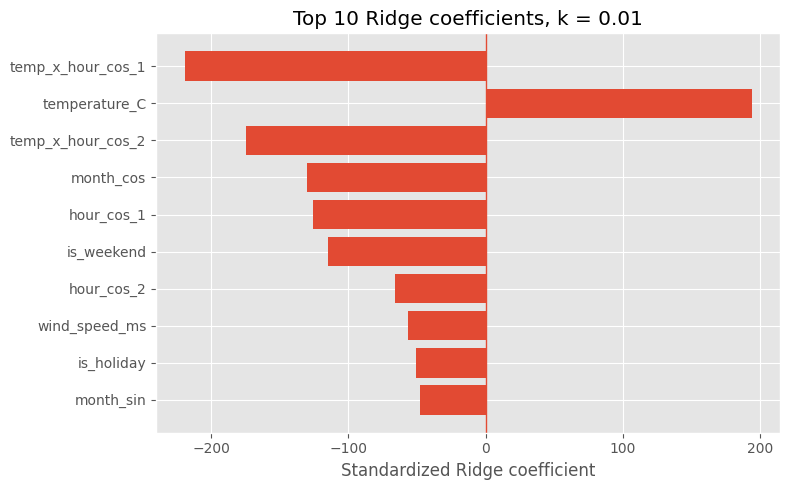

In [98]:
coef_plot = coef_table.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(coef_plot["feature"], coef_plot["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Ridge coefficient")
plt.title("Top 10 Ridge coefficients, k = 0.01")
plt.tight_layout()
plt.show()